# Graph-Structured Latent Covariance Learning for GMV Portfolio Optimization

**Pipeline:** $X_t \to A_t \to \text{GNN}_\theta \to H_t \to w^* \to \mathcal{L}$

($\Sigma_t = H_t H_t^\top + \epsilon I$ is implicit inside the GMV objective)

| Loss | Formula | Purpose |
|---|---|---|
| $\mathcal{L}_1$ | $w^{*\top} \hat{\Sigma}_t w^*$ | Pure variance minimization |
| $\mathcal{L}_2$ | $-\frac{(w^*)^\top r_{t+1}}{\sqrt{w^{*\top} \hat{\Sigma}_t w^* + \epsilon}}$ | Negative Sharpe |

In [53]:
# !pip install torch torch-geometric cvxpy cvxpylayers yfinance scipy -q

In [85]:
import importlib
import numpy as np
import torch
import torch.nn as nn
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import models, dataset, losses
importlib.reload(models)
importlib.reload(dataset)
importlib.reload(losses)

from models  import GraphGMVModel
from dataset import PortfolioDataset, compute_adjacency
from losses  import loss_variance, loss_sharpe

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
print(f'Device: {device}')

Device: cpu


## 1. Configuration

In [86]:
TICKERS = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'BRK-B', 'UNH', 'JNJ',
    'XOM',  'JPM',  'V',     'PG',   'MA',   'HD',   'CVX',   'MRK', 'ABBV',
    'PEP',  'KO',   'AVGO',  'COST', 'MCD',  'WMT',  'BAC',   'ACN', 'LLY',
    'TMO',  'CSCO', 'NFLX'
]

SECTORS = {
    'Tech'      : ['AAPL','MSFT','GOOGL','NVDA','META','AVGO','CSCO','NFLX','ACN'],
    'Consumer'  : ['AMZN','MCD','COST','WMT','PEP','KO','HD'],
    'Healthcare': ['UNH','JNJ','MRK','ABBV','LLY','TMO'],
    'Finance'   : ['JPM','V','MA','BAC','BRK-B'],
    'Energy'    : ['XOM','CVX'],
}
SECTOR_COLORS   = {'Tech':'#4C72B0','Consumer':'#DD8452','Healthcare':'#55A868',
                   'Finance':'#C44E52','Energy':'#8172B3'}
ticker_to_sector = {t: s for s, ts in SECTORS.items() for t in ts}

CFG = {
    'tickers'        : TICKERS,
    'start'          : '2010-01-01',
    'end'            : '2025-12-31',
    'lookback'       : 504,    # 2yr  feature window per sample
    'horizon'        : 126,    # 6m   r_next & inner fold period
    'rebalance_freq' : 21,     # 1m   slide step (monthly rebalancing)
    'corr_threshold' : 0.3,    # |Pearson| threshold for adjacency
    'n_features'     : 7,
    'd_hidden'       : 32,
    'd_latent'       : 16,
    'epsilon'        : 1e-4,
    'lr'             : 1e-3,
    'n_epochs'       : 500,
    'patience'       : 50,
    'train_ratio'    : 0.6,
    'val_ratio'      : 0.2,
}

N = len(TICKERS)
print(f'Universe: {N} assets')

Universe: 30 assets


## 2. Data Loading

In [87]:
prices  = yf.download(CFG['tickers'], start=CFG['start'], end=CFG['end'],
                      auto_adjust=True, progress=False)['Close']
prices  = prices[CFG['tickers']].dropna()
returns = prices.pct_change().dropna()

print(f'Returns shape: {returns.shape}')
print(f'Date range   : {returns.index[0].date()} ~ {returns.index[-1].date()}')

Returns shape: (3268, 30)
Date range   : 2013-01-03 ~ 2025-12-30


## 3. Dataset

In [88]:
returns_arr = returns.values.astype(np.float32)
T           = len(returns_arr)
lookback    = CFG['lookback']
horizon     = CFG['horizon']
freq        = CFG['rebalance_freq']


def make_rolling_folds(T, lookback, horizon, rebal_freq):
    """
    전체 데이터를 lookback+horizon 창으로 슬라이드 (step=horizon).
      window : [fold_start : fold_start+lookback]   → X_t, A_t 계산 기준
      horizon: [fold_start+lookback : +horizon]     → r_next 평가 구간
    """
    folds = []
    fold_start = 0
    while fold_start + lookback + horizon <= T:
        w_s = fold_start
        w_e = fold_start + lookback
        h_e = w_e + horizon
        folds.append({
            'window_slice' : (w_s, w_e),
            'horizon_slice': (w_e, h_e),
            'indices'      : list(range(w_e, h_e, rebal_freq)),
        })
        fold_start += horizon
    return folds


# 유효 리밸런싱 날짜: lookback 이후, r_next(=horizon일) 확보 가능한 시점
all_indices = list(range(lookback, T - horizon, freq))
n_total     = len(all_indices)
n_train     = int(n_total * CFG['train_ratio'])
n_val       = int(n_total * CFG['val_ratio'])

idx_train = all_indices[:n_train]
idx_val   = all_indices[n_train : n_train + n_val]
idx_test  = all_indices[n_train + n_val:]

print('Pre-computing datasets...')
train_ds = PortfolioDataset(returns_arr, idx_train, lookback,
                            holding_period=horizon, corr_threshold=CFG['corr_threshold'])
val_ds   = PortfolioDataset(returns_arr, idx_val,   lookback,
                            holding_period=horizon, corr_threshold=CFG['corr_threshold'])
test_ds  = PortfolioDataset(returns_arr, idx_test,  lookback,
                            holding_period=horizon, corr_threshold=CFG['corr_threshold'])

def fmt_period(indices):
    s = returns.index[indices[0]].date()
    e = returns.index[indices[-1]].date()
    return f'{s} ~ {e}'

print(f'Train : {len(train_ds):3d} samples  {fmt_period(idx_train)}')
print(f'Val   : {len(val_ds):3d} samples  {fmt_period(idx_val)}')
print(f'Test  : {len(test_ds):3d} samples  {fmt_period(idx_test)}')

folds_all = make_rolling_folds(T, lookback, horizon, freq)
print(f'\nInner rolling folds (전체 데이터): {len(folds_all)}개')

Pre-computing datasets...
Train :  75 samples  2015-01-05 ~ 2021-03-09
Val   :  25 samples  2021-04-08 ~ 2023-04-10
Test  :  26 samples  2023-05-09 ~ 2025-06-12

Inner rolling folds (전체 데이터): 21개


Window : 2013-01-03 ~ 2015-01-02
Horizon: 2015-01-05 ~ 2015-07-06
Edges  : 204/435  (density=46.9%,  threshold=0.3)
Degree : mean=13.6,  min=1,  max=26


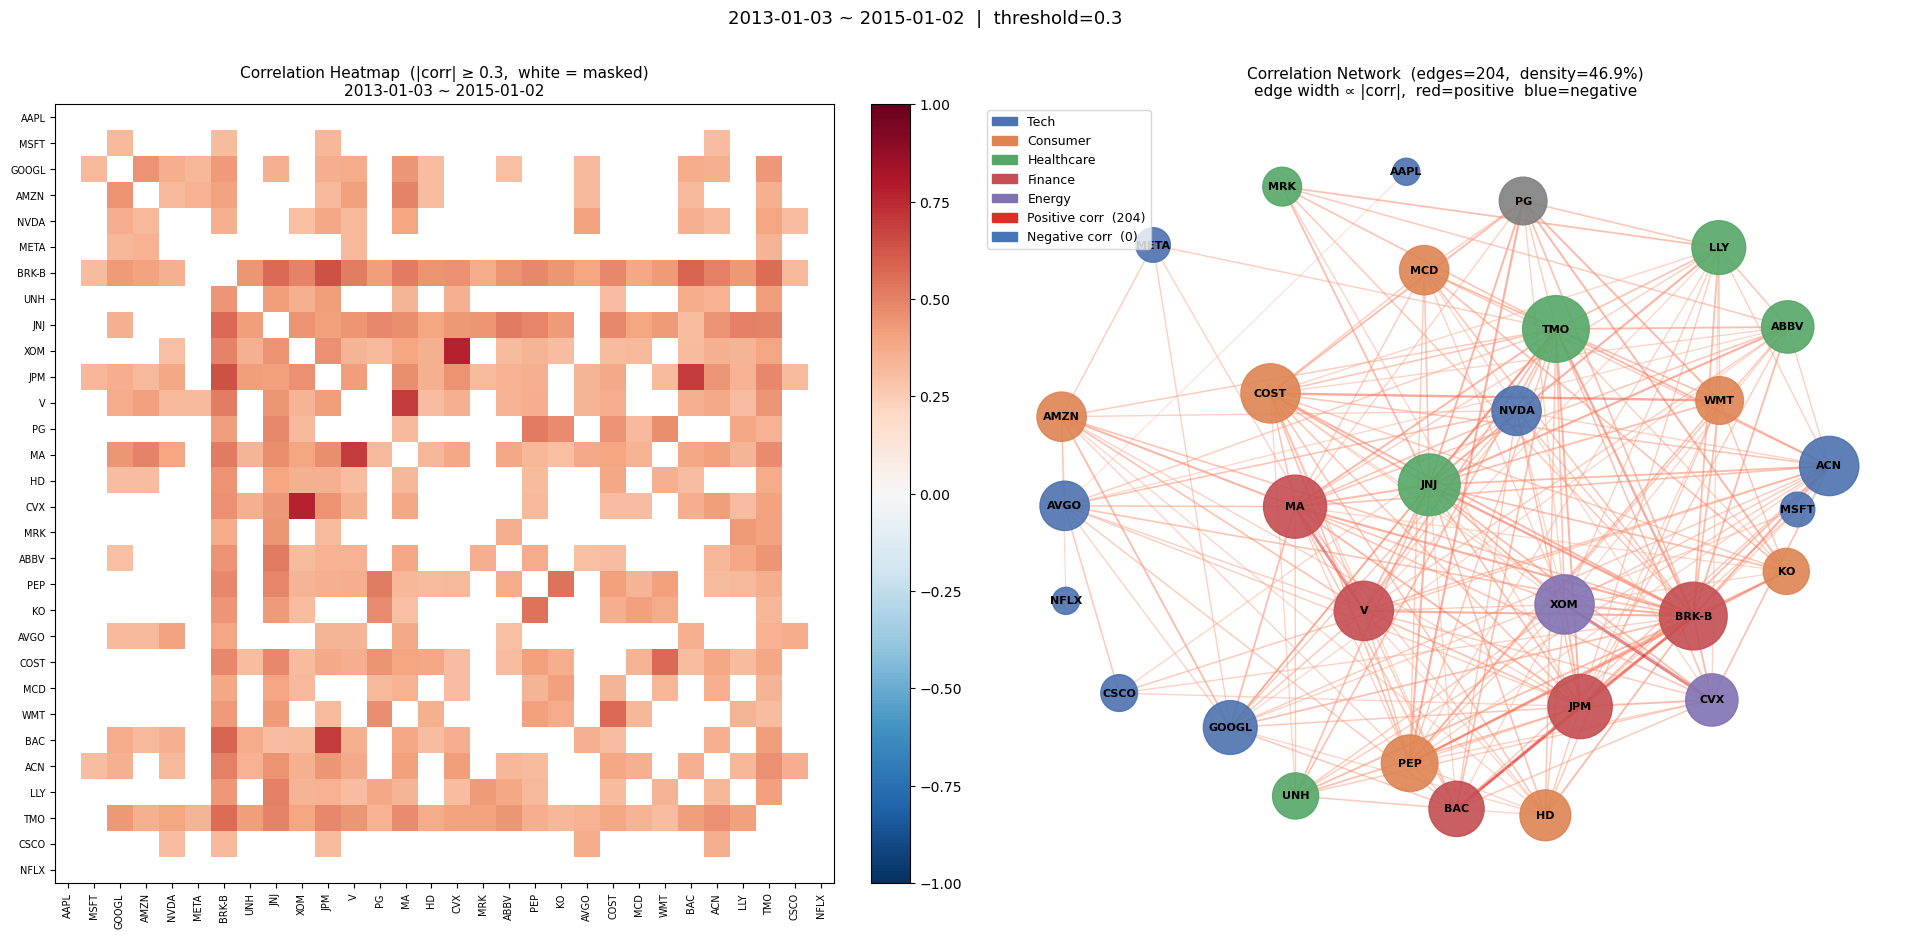


Positive edges: 204  |  Negative edges: 0


In [89]:
import networkx as nx

# ── 3-B. 첫 번째 Rolling Window 그래프 구조 시각화 ──────────────────────────
f0       = folds_all[0]
w_s, w_e = f0['window_slice']
h_s, h_e = f0['horizon_slice']
window0  = returns_arr[w_s:w_e]

# GCN 입력: |corr| 기반 thresholded adjacency
adj0  = compute_adjacency(window0, threshold=CFG['corr_threshold'])
# 시각화 전용: 부호 포함 원본 corr
corr0 = np.corrcoef(window0.T)

n_edges    = int((adj0 > 0).sum() // 2)
n_possible = N * (N - 1) // 2
density    = n_edges / n_possible
degree     = (adj0 > 0).sum(axis=1)

print(f'Window : {returns.index[w_s].date()} ~ {returns.index[w_e-1].date()}')
print(f'Horizon: {returns.index[h_s].date()} ~ {returns.index[h_e-1].date()}')
print(f'Edges  : {n_edges}/{n_possible}  (density={density:.1%},  threshold={CFG["corr_threshold"]})')
print(f'Degree : mean={degree.mean():.1f},  min={degree.min()},  max={degree.max()}')

# ── 그래프 구성 ─────────────────────────────────────────────────────────────
G = nx.Graph()
G.add_nodes_from(TICKERS)
for i in range(N):
    for j in range(i + 1, N):
        if adj0[i, j] > 0:
            G.add_edge(TICKERS[i], TICKERS[j],
                       weight=float(adj0[i, j]),          # |corr| → 두께
                       sign=float(np.sign(corr0[i, j])))  # 부호 → 색깔

pos_edges = [(u, v) for u, v, d in G.edges(data=True) if d['sign'] > 0]
neg_edges = [(u, v) for u, v, d in G.edges(data=True) if d['sign'] < 0]
pos_w     = [G[u][v]['weight'] for u, v in pos_edges]
neg_w     = [G[u][v]['weight'] for u, v in neg_edges]

node_colors = [SECTOR_COLORS.get(ticker_to_sector.get(t, 'Other'), 'gray') for t in TICKERS]
node_sizes  = [300 + degree[TICKERS.index(t)] * 80 for t in TICKERS]

for u, v, d in G.edges(data=True):
    d['inv_weight'] = 1.0 - d['weight']
pos = nx.spring_layout(G, weight='inv_weight', seed=42, k=2.5)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# ── Left: adjacency heatmap (부호 포함, 발산형 컬러맵) ──────────────────────
ax = axes[0]
# threshold 미만은 마스킹 → 흰색
corr_masked = np.where(np.abs(corr0) >= CFG['corr_threshold'], corr0, np.nan)
np.fill_diagonal(corr_masked, np.nan)

cmap = plt.cm.RdBu_r
cmap.set_bad('white')
im = ax.imshow(corr_masked, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels(TICKERS, rotation=90, fontsize=7)
ax.set_yticklabels(TICKERS, fontsize=7)
ax.set_title(f'Correlation Heatmap  (|corr| ≥ {CFG["corr_threshold"]},  white = masked)\n'
             f'{returns.index[w_s].date()} ~ {returns.index[w_e-1].date()}', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ── Right: network graph ────────────────────────────────────────────────────
ax = axes[1]
nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

if pos_edges:
    nx.draw_networkx_edges(G, pos, edgelist=pos_edges,
                           width=[w * 3 for w in pos_w],
                           edge_color=pos_w, edge_cmap=plt.cm.Reds,
                           edge_vmin=0, edge_vmax=1, alpha=0.5, ax=ax)
if neg_edges:
    nx.draw_networkx_edges(G, pos, edgelist=neg_edges,
                           width=[w * 3 for w in neg_w],
                           edge_color=neg_w, edge_cmap=plt.cm.Blues,
                           edge_vmin=0, edge_vmax=1, alpha=0.5, ax=ax)

patches  = [mpatches.Patch(color=c, label=s) for s, c in SECTOR_COLORS.items()]
patches += [mpatches.Patch(color='#d73027', label=f'Positive corr  ({len(pos_edges)})'),
            mpatches.Patch(color='#4575b4', label=f'Negative corr  ({len(neg_edges)})')]
ax.legend(handles=patches, fontsize=9, loc='upper left')
ax.set_title(f'Correlation Network  (edges={n_edges},  density={density:.1%})\n'
             f'edge width ∝ |corr|,  red=positive  blue=negative', fontsize=11)
ax.axis('off')

plt.suptitle(f'{returns.index[w_s].date()} ~ {returns.index[w_e-1].date()}  '
             f'|  threshold={CFG["corr_threshold"]}', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('graph_structure_fold1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nPositive edges: {len(pos_edges)}  |  Negative edges: {len(neg_edges)}')

## 4. Sanity Check

In [72]:
s        = train_ds[0]
m_tmp    = GraphGMVModel(N, CFG['n_features'], CFG['d_hidden'], CFG['d_latent'])
w_t, H_t = m_tmp(s['x'], s['edge_index'], s['edge_weight'])
S_t      = m_tmp.compute_sigma(H_t)
print(f'w_star: shape={tuple(w_t.shape)}, sum={w_t.sum().item():.4f}, min={w_t.min().item():.4f}')
print(f'Sigma : shape={tuple(S_t.shape)}, PSD={bool((torch.linalg.eigvalsh(S_t) > 0).all())}')
print(f'H     : shape={tuple(H_t.shape)}')

w_star: shape=(30,), sum=1.0000, min=-0.0000
Sigma : shape=(30, 30), PSD=True
H     : shape=(30, 16)


In [73]:
# ── Gradient flow verification ──────────────────────────────────────────
# Check 1: w_star has grad_fn  (cvxpylayers attached to computation graph)
# Check 2: gradients reach GNN parameters  (end-to-end)

m_tmp.train()
s = train_ds[0]
x_v  = s['x'].requires_grad_(False)
ei_v = s['edge_index']
ew_v = s['edge_weight']
sig_v = s['sigma_sample']
r_v   = s['r_next']

w_star, H = m_tmp(x_v, ei_v, ew_v)

print(f'[1] w_star.grad_fn : {w_star.grad_fn}')       # should not be None
print(f'    H.grad_fn      : {H.grad_fn}')

loss = loss_variance(w_star, r_v, sig_v)
loss.backward()

grads = {name: (p.grad is not None) for name, p in m_tmp.named_parameters()}
all_have_grad = all(grads.values())
print(f'\n[2] Gradients reached all GNN parameters: {all_have_grad}')
for name, has_grad in grads.items():
    print(f'    {name:<40} grad={has_grad}')

[1] w_star.grad_fn : <ToCopyBackward0 object at 0x174affe80>
    H.grad_fn      : <DivBackward0 object at 0x175e6eaa0>

[2] Gradients reached all GNN parameters: True
    gnn.conv1.bias                           grad=True
    gnn.conv1.lin.weight                     grad=True
    gnn.conv2.bias                           grad=True
    gnn.conv2.lin.weight                     grad=True
    gnn.bn1.weight                           grad=True
    gnn.bn1.bias                             grad=True


## 4-B. Embedding Diagnostics

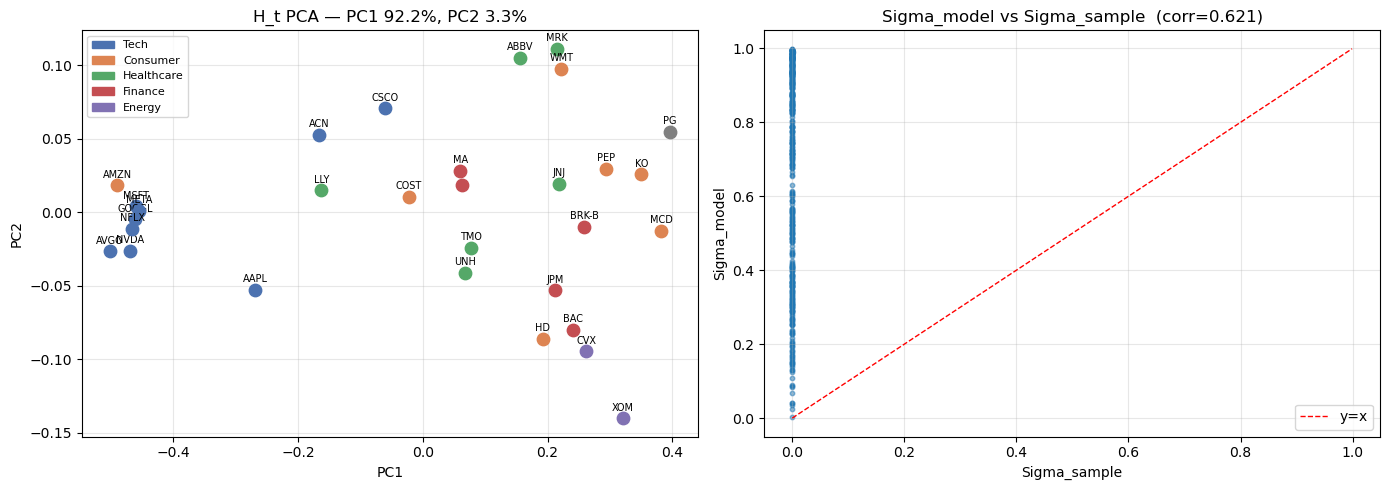

PCA explained variance: PC1=92.2%, PC2=3.3%
Sigma correlation (model vs sample): 0.6209


In [74]:
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

# ── Sector map ────────────────────────────────────────────────────────────
SECTORS = {
    'Tech'      : ['AAPL','MSFT','GOOGL','NVDA','META','AVGO','CSCO','NFLX','ACN'],
    'Consumer'  : ['AMZN','MCD','COST','WMT','PEP','KO','HD'],
    'Healthcare': ['UNH','JNJ','MRK','ABBV','LLY','TMO'],
    'Finance'   : ['JPM','V','MA','BAC','BRK-B'],
    'Energy'    : ['XOM','CVX'],
}
SECTOR_COLORS = {'Tech':'#4C72B0','Consumer':'#DD8452','Healthcare':'#55A868',
                 'Finance':'#C44E52','Energy':'#8172B3'}
ticker_to_sector = {t: s for s, ts in SECTORS.items() for t in ts}

# ── Collect H_t across all test samples ───────────────────────────────────
m_tmp.eval()
H_list = []
with torch.no_grad():
    for s in test_ds:
        _, H = m_tmp(s['x'], s['edge_index'], s['edge_weight'])
        H_list.append(H.numpy())           # (N, d_latent)

H_all = np.stack(H_list, axis=0)          # (T_test, N, d_latent)
H_mean = H_all.mean(axis=0)               # (N, d_latent) — time-averaged embedding

# ── PCA: 2D projection ────────────────────────────────────────────────────
pca   = PCA(n_components=2)
H_2d  = pca.fit_transform(H_mean)         # (N, 2)
var_explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter colored by sector
ax = axes[0]
for ticker, (x, y) in zip(TICKERS, H_2d):
    sector = ticker_to_sector.get(ticker, 'Other')
    color  = SECTOR_COLORS.get(sector, 'gray')
    ax.scatter(x, y, color=color, s=80, zorder=3)
    ax.annotate(ticker, (x, y), fontsize=7, ha='center', va='bottom',
                xytext=(0, 4), textcoords='offset points')

patches = [mpatches.Patch(color=c, label=s) for s, c in SECTOR_COLORS.items()]
ax.legend(handles=patches, fontsize=8, loc='best')
ax.set_title(f'H_t PCA — PC1 {var_explained[0]:.1%}, PC2 {var_explained[1]:.1%}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.grid(alpha=0.3)

# Right: Sigma_model vs Sigma_sample (first test sample)
ax   = axes[1]
s0   = test_ds[0]
with torch.no_grad():
    _, H0 = m_tmp(s0['x'], s0['edge_index'], s0['edge_weight'])
Sigma_model  = m_tmp.compute_sigma(H0).numpy()
Sigma_sample = s0['sigma_sample'].numpy()

# Scatter: off-diagonal elements only
mask = ~np.eye(N, dtype=bool)
ax.scatter(Sigma_sample[mask], Sigma_model[mask], alpha=0.3, s=10)
lims = [min(Sigma_sample[mask].min(), Sigma_model[mask].min()),
        max(Sigma_sample[mask].max(), Sigma_model[mask].max())]
ax.plot(lims, lims, 'r--', linewidth=1, label='y=x')
corr = np.corrcoef(Sigma_sample[mask], Sigma_model[mask])[0, 1]
ax.set_title(f'Sigma_model vs Sigma_sample  (corr={corr:.3f})')
ax.set_xlabel('Sigma_sample'); ax.set_ylabel('Sigma_model')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('embedding_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'PCA explained variance: PC1={var_explained[0]:.1%}, PC2={var_explained[1]:.1%}')
print(f'Sigma correlation (model vs sample): {corr:.4f}')

## 5. Training

In [61]:
def run_epoch(model, dataset, optimizer, loss_fn, train, device):
    model.train(train)
    total = 0.0
    ctx   = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for s in dataset:
            x, ei, ew = s['x'].to(device), s['edge_index'].to(device), s['edge_weight'].to(device)
            sig, r    = s['sigma_sample'].to(device), s['r_next'].to(device)
            if train:
                optimizer.zero_grad()
            w_star, _ = model(x, ei, ew)
            loss      = loss_fn(w_star, r, sig)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total += loss.item()
    return total / len(dataset)


def train_model(loss_fn, loss_name):
    model     = GraphGMVModel(N, CFG['n_features'], CFG['d_hidden'],
                              CFG['d_latent'], CFG['epsilon']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_val, best_state, pat = float('inf'), None, 0
    tr_hist, val_hist = [], []

    for epoch in range(1, CFG['n_epochs'] + 1):
        tr  = run_epoch(model, train_ds, optimizer, loss_fn, True,  device)
        val = run_epoch(model, val_ds,   optimizer, loss_fn, False, device)
        scheduler.step(val)
        tr_hist.append(tr)
        val_hist.append(val)

        if val < best_val:
            best_val   = val
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            pat        = 0
        else:
            pat += 1

        if pat >= CFG['patience']:
            print(f'[{loss_name}] Early stop @ epoch {epoch}')
            break
        if epoch % 10 == 0:
            print(f'[{loss_name}] Ep {epoch:3d} | Train {tr:.6f} | Val {val:.6f}')

    model.load_state_dict(best_state)
    return model, tr_hist, val_hist

In [62]:
print('=' * 50)
print('Training  L1  (Variance Loss)')
print('=' * 50)
model_l1, hist_tr_l1, hist_val_l1 = train_model(loss_variance, 'L1-Var')

print()
print('=' * 50)
print('Training  L2  (Sharpe Loss)')
print('=' * 50)
model_l2, hist_tr_l2, hist_val_l2 = train_model(loss_sharpe, 'L2-Sharpe')

Training  L1  (Variance Loss)
[L1-Var] Ep  10 | Train 0.000109 | Val 0.000270
[L1-Var] Ep  20 | Train 0.000090 | Val 0.000275
[L1-Var] Ep  30 | Train 0.000086 | Val 0.000274
[L1-Var] Ep  40 | Train 0.000082 | Val 0.000276
[L1-Var] Ep  50 | Train 0.000081 | Val 0.000273
[L1-Var] Ep  60 | Train 0.000081 | Val 0.000271
[L1-Var] Early stop @ epoch 64

Training  L2  (Sharpe Loss)
[L2-Sharpe] Ep  10 | Train -3.832444 | Val -1.748378
[L2-Sharpe] Ep  20 | Train -4.487509 | Val -2.155096
[L2-Sharpe] Ep  30 | Train -4.725553 | Val -2.200705
[L2-Sharpe] Ep  40 | Train -5.305075 | Val -2.234529
[L2-Sharpe] Ep  50 | Train -5.663528 | Val -2.025708
[L2-Sharpe] Ep  60 | Train -5.761160 | Val -1.895701
[L2-Sharpe] Ep  70 | Train -5.813422 | Val -1.700839
[L2-Sharpe] Early stop @ epoch 74


## 6. Evaluation

In [63]:
@torch.no_grad()
def get_weights(model, dataset, device):
    model.eval()
    ws, rs = [], []
    for s in dataset:
        w, _ = model(s['x'].to(device), s['edge_index'].to(device), s['edge_weight'].to(device))
        ws.append(w.cpu().numpy())
        rs.append(s['r_next'].numpy())
    return np.array(ws), np.array(rs)


def portfolio_metrics(w, r, freq=5, ann=252):
    pr  = (w * r).sum(axis=1)
    af  = ann / freq
    mu  = pr.mean() * af
    sig = pr.std()  * np.sqrt(af)
    cum = np.cumprod(1 + pr)
    pk  = np.maximum.accumulate(cum)
    mdd = ((cum - pk) / pk).min()
    return {
        'Ann. Return': mu, 'Ann. Vol': sig, 'Sharpe': mu / (sig + 1e-8),
        'Max DD': mdd,     'Calmar': mu / (-mdd + 1e-8),
        'cum_ret': cum,    'port_ret': pr,
    }


def ew_baseline(ds):
    return np.tile(1.0 / N, (len(ds), N)), np.array([s['r_next'].numpy() for s in ds])


def sample_gmv_baseline(ds):
    """Classic GMV: sample covariance, closed-form, long-only clipped."""
    ws, rs = [], []
    for s in ds:
        sig = s['sigma_sample'].numpy()
        try:
            inv = np.linalg.inv(sig + 1e-4 * np.eye(N))
            w   = inv @ np.ones(N)
            w   = np.clip(w, 0, None)
            w  /= w.sum() + 1e-8
        except np.linalg.LinAlgError:
            w = np.ones(N) / N
        ws.append(w)
        rs.append(s['r_next'].numpy())
    return np.array(ws), np.array(rs)

In [64]:
w_l1, r_test = get_weights(model_l1, test_ds, device)
w_l2, _      = get_weights(model_l2, test_ds, device)
w_ew,  r_ew  = ew_baseline(test_ds)
w_gmv, r_gmv = sample_gmv_baseline(test_ds)

m_ew  = portfolio_metrics(w_ew,  r_ew,   CFG['rebalance_freq'])
m_gmv = portfolio_metrics(w_gmv, r_gmv,  CFG['rebalance_freq'])
m_l1  = portfolio_metrics(w_l1,  r_test, CFG['rebalance_freq'])
m_l2  = portfolio_metrics(w_l2,  r_test, CFG['rebalance_freq'])

keys = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max DD', 'Calmar']
hdr  = f"{'Metric':<14}{'EW':>10}{'Sample GMV':>12}{'Graph-L1':>12}{'Graph-L2':>12}"
print('=' * len(hdr))
print(hdr)
print('=' * len(hdr))
for k in keys:
    print(f"{k:<14}{m_ew[k]:>10.4f}{m_gmv[k]:>12.4f}{m_l1[k]:>12.4f}{m_l2[k]:>12.4f}")
print('=' * len(hdr))

Metric                EW  Sample GMV    Graph-L1    Graph-L2
Ann. Return       0.2425      0.1490      0.3790      0.2132
Ann. Vol          0.1348      0.1148      0.1939      0.1845
Sharpe            1.7995      1.2988      1.9543      1.1557
Max DD           -0.1323     -0.1048     -0.1399     -0.1175
Calmar            1.8335      1.4216      2.7098      1.8143


## 7. Visualization

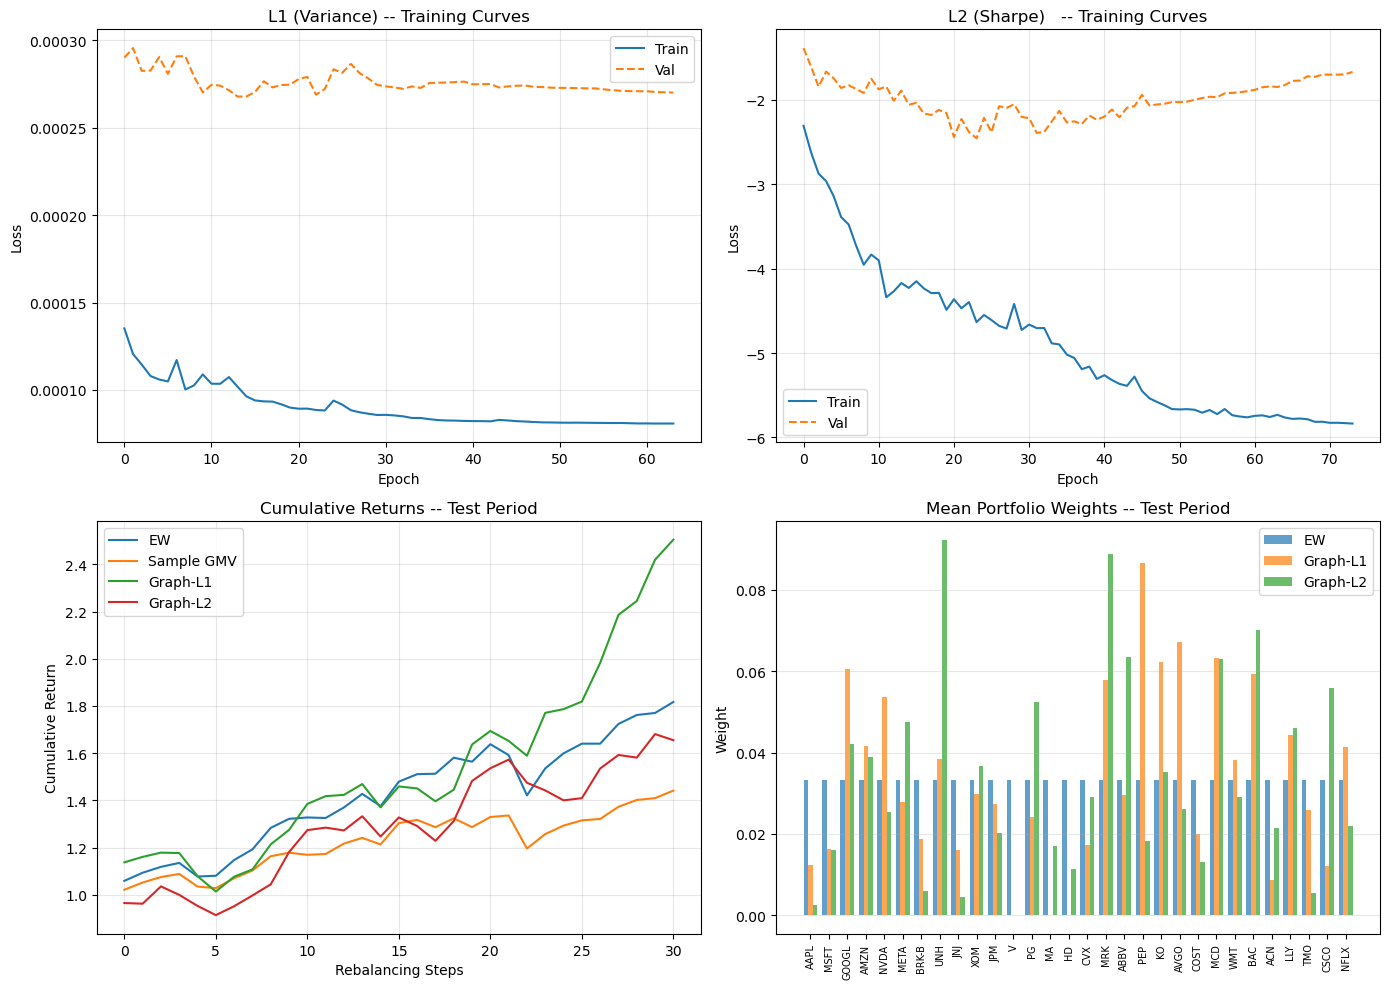

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, tr, val, title in [
    (axes[0,0], hist_tr_l1, hist_val_l1, 'L1 (Variance) -- Training Curves'),
    (axes[0,1], hist_tr_l2, hist_val_l2, 'L2 (Sharpe)   -- Training Curves'),
]:
    ax.plot(tr, label='Train')
    ax.plot(val, label='Val', linestyle='--')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

ax = axes[1,0]
for m, label in [(m_ew,'EW'), (m_gmv,'Sample GMV'), (m_l1,'Graph-L1'), (m_l2,'Graph-L2')]:
    ax.plot(m['cum_ret'], label=label)
ax.set_title('Cumulative Returns -- Test Period')
ax.set_xlabel('Rebalancing Steps'); ax.set_ylabel('Cumulative Return')
ax.legend(); ax.grid(alpha=0.3)

ax    = axes[1,1]
x_pos = np.arange(N)
bw    = 0.25
ax.bar(x_pos-bw, w_ew.mean(0),  bw, label='EW',       alpha=0.7)
ax.bar(x_pos,    w_l1.mean(0),  bw, label='Graph-L1', alpha=0.7)
ax.bar(x_pos+bw, w_l2.mean(0),  bw, label='Graph-L2', alpha=0.7)
ax.set_title('Mean Portfolio Weights -- Test Period')
ax.set_xticks(x_pos); ax.set_xticklabels(TICKERS, rotation=90, fontsize=7)
ax.set_ylabel('Weight'); ax.legend(); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Concentration Analysis

In [66]:
def hhi(w):         return (w ** 2).sum(axis=1).mean()
def effective_n(w): return 1.0 / hhi(w)

print('Portfolio concentration (test period):')
for name, w in [('Equal Weight', w_ew), ('Sample GMV', w_gmv),
                ('Graph-L1',     w_l1), ('Graph-L2',   w_l2)]:
    print(f'  {name:<14}  HHI={hhi(w):.4f}  Eff-N={effective_n(w):.2f}')

Portfolio concentration (test period):
  Equal Weight    HHI=0.0333  Eff-N=30.00
  Sample GMV      HHI=0.0585  Eff-N=17.09
  Graph-L1        HHI=0.3589  Eff-N=2.79
  Graph-L2        HHI=0.3913  Eff-N=2.56
